In [1]:
# exploratory data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

project_folder = Path.cwd()
if project_folder.name == "notebooks":
    project_folder = project_folder.parent

data_folder = project_folder / "data" / "processed"

files = {
    "users": "cleaned_users.csv",
    "channels": "cleaned_channels.csv",
    "videos": "cleaned_videos.csv",
    "sessions": "cleaned_sessions.csv",
    "events": "cleaned_events.csv",
    "experiments": "cleaned_experiment_assignments.csv"
}

missing_files = [name for name in files.values() if not (data_folder / name).exists()]
if missing_files:
    raise FileNotFoundError("Missing files: " + ", ".join(missing_files))

users = pd.read_csv(data_folder / files["users"], parse_dates=["signup_date"], low_memory=False)
channels = pd.read_csv(data_folder / files["channels"], low_memory=False)
videos = pd.read_csv(data_folder / files["videos"], parse_dates=["upload_date"], low_memory=False)
sessions = pd.read_csv(
    data_folder / files["sessions"],
    parse_dates=["session_start_timestamp", "session_end_timestamp"],
    low_memory=False
)
events = pd.read_csv(
    data_folder / files["events"],
    usecols=["event_timestamp", "event_name", "video_id"],
    parse_dates=["event_timestamp"],
    low_memory=False
)
experiments = pd.read_csv(
    data_folder / files["experiments"],
    parse_dates=["assignment_date", "first_exposure_date"],
    low_memory=False
)

if "session_duration_minutes" not in sessions.columns:
    sessions["session_duration_minutes"] = (
        sessions["session_end_timestamp"] - sessions["session_start_timestamp"]
    ).dt.total_seconds() / 60

experiments["eligible_flag"] = (
    experiments["eligible_flag"].astype(str).str.lower().eq("true")
)

print("Data loaded")

Data loaded


In [2]:
# dataset overview
overview = pd.DataFrame({
    "metric": [
        "Total users", "Total channels", "Total videos",
        "Total sessions", "Total events", "Experiment participants"
    ],
    "value": [
        users["user_id"].nunique(),
        channels["channel_id"].nunique(),
        videos["video_id"].nunique(),
        sessions["session_id"].nunique(),
        len(events),
        experiments["user_id"].nunique()
    ]
})

display(overview)
print("Event date range:", events["event_timestamp"].min(), "to", events["event_timestamp"].max())

,metric,value
0,Total users,25000
1,Total channels,2000
2,Total videos,10000
3,Total sessions,216464
4,Total events,1609012
5,Experiment participants,12500


Event date range: 2025-07-27 00:20:07 to 2026-07-26 00:02:12


In [3]:
# small chart functions
def bar_chart(data, title, x_label="", y_label="Count", rotation=0, sort=True):
    if sort:
        data = data.sort_values(ascending=False)

    plt.figure(figsize=(9, 4))
    plt.bar(data.index.astype(str), data.values)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()


def line_chart(data, title, x_label="", y_label="Count"):
    plt.figure(figsize=(10, 4))
    plt.plot(data.index, data.values)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

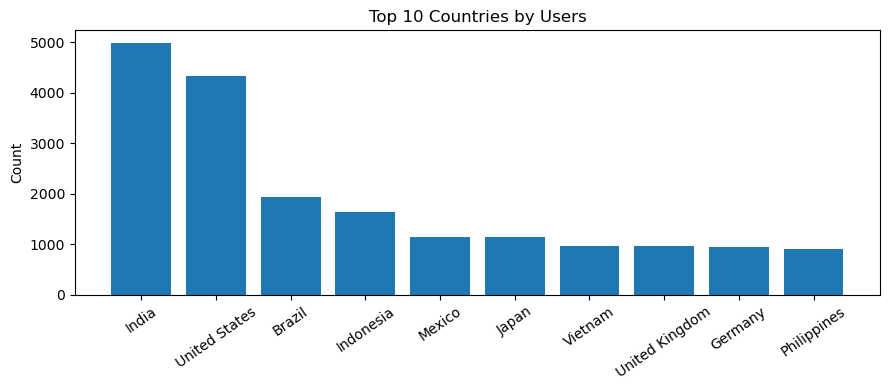

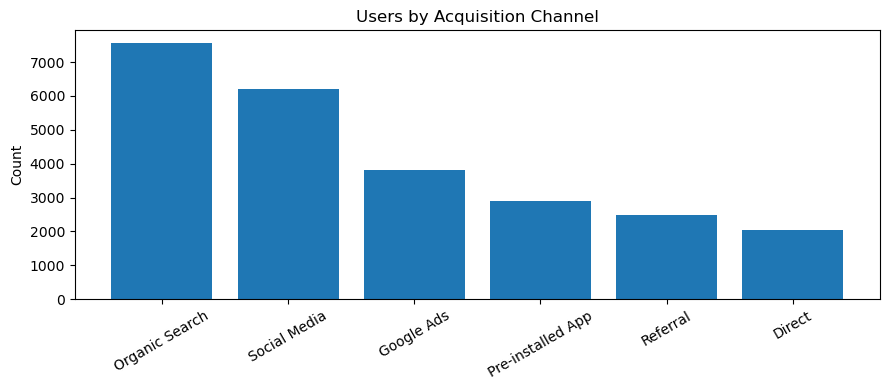

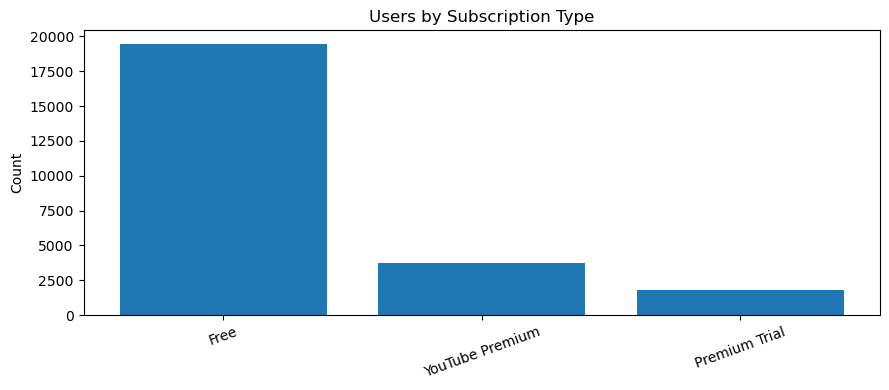

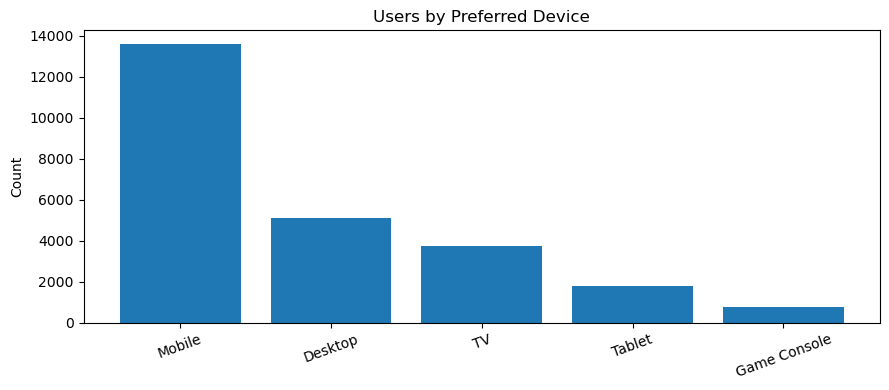

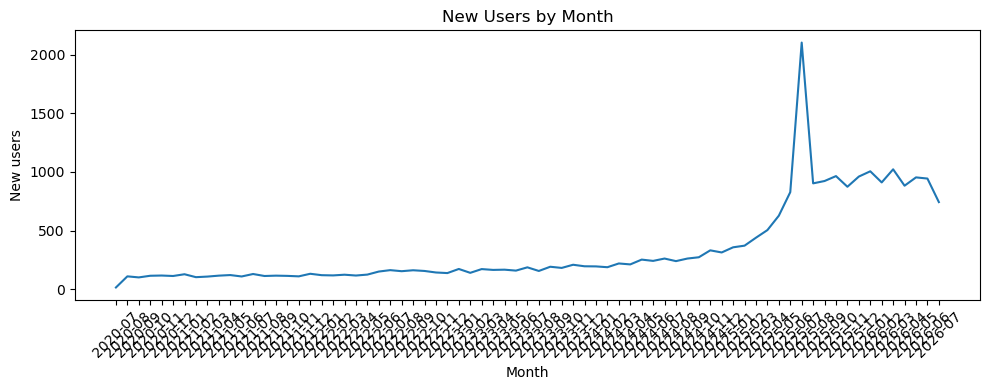

User observations
Top country: India
Top acquisition channel: Organic Search
Most common subscription: Free
Most preferred device: Mobile


In [4]:
# user analysis
users_by_country = users["country"].value_counts().head(10)
users_by_acquisition = users["acquisition_channel"].value_counts()
users_by_subscription = users["subscription_type"].value_counts()
users_by_device = users["preferred_device"].value_counts()
new_users_by_month = users.groupby(users["signup_date"].dt.to_period("M")).size()
new_users_by_month.index = new_users_by_month.index.astype(str)

bar_chart(users_by_country, "Top 10 Countries by Users", rotation=35)
bar_chart(users_by_acquisition, "Users by Acquisition Channel", rotation=30)
bar_chart(users_by_subscription, "Users by Subscription Type", rotation=20)
bar_chart(users_by_device, "Users by Preferred Device", rotation=20)
line_chart(new_users_by_month, "New Users by Month", "Month", "New users")

print("User observations")
print("Top country:", users_by_country.idxmax())
print("Top acquisition channel:", users_by_acquisition.idxmax())
print("Most common subscription:", users_by_subscription.idxmax())
print("Most preferred device:", users_by_device.idxmax())

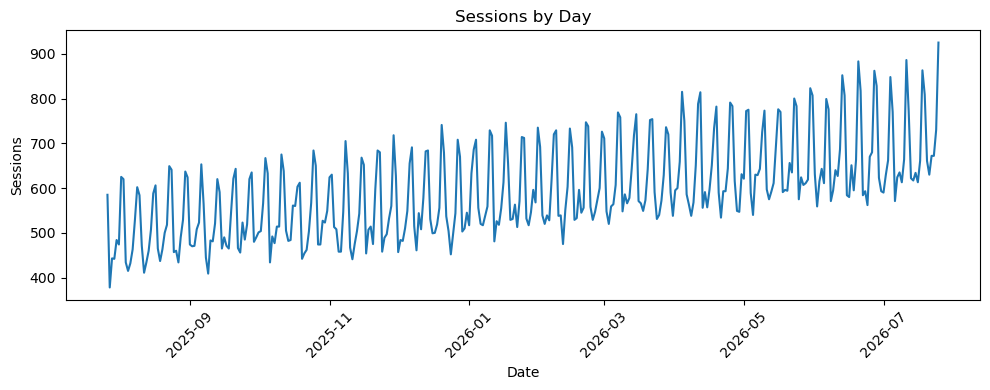

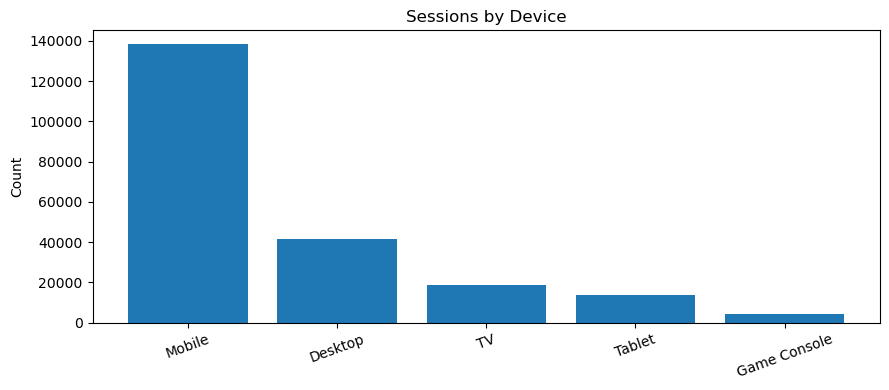

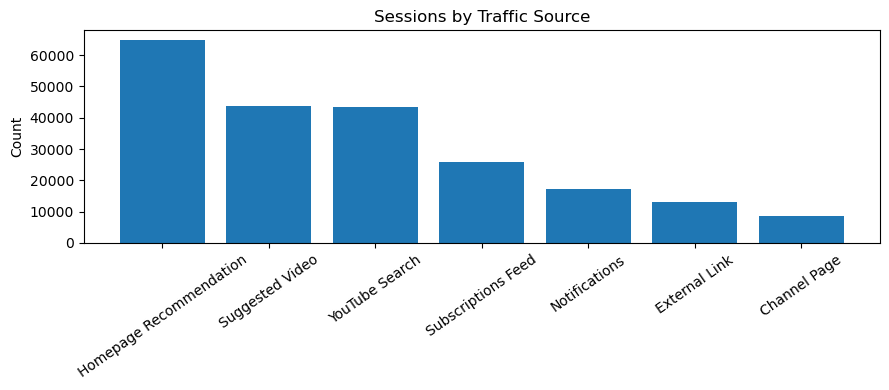

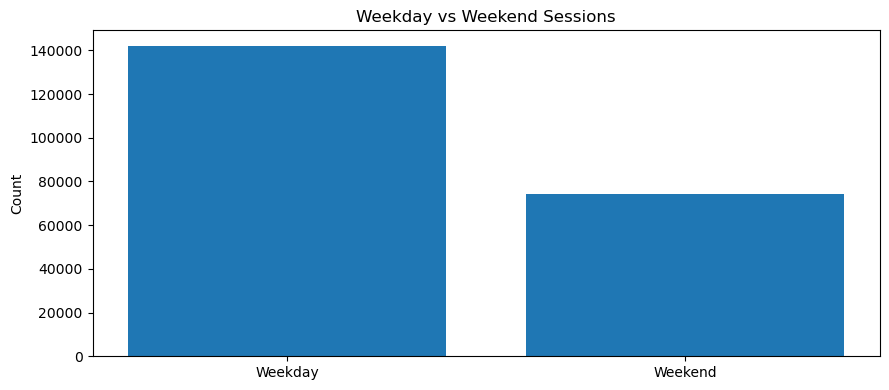

Session observations
Average session duration: 6.01 minutes
Top session device: Mobile
Top traffic source: Homepage Recommendation
Busiest day: 2026-07-25


In [5]:
# session analysis
sessions_by_day = sessions.groupby(
    sessions["session_start_timestamp"].dt.floor("D")
).size()

sessions_by_device = sessions["device_type"].value_counts()
sessions_by_source = sessions["traffic_source"].value_counts()

session_day_type = np.where(
    sessions["session_start_timestamp"].dt.dayofweek >= 5,
    "Weekend",
    "Weekday"
)
weekday_sessions = pd.Series(session_day_type).value_counts()
avg_session_minutes = sessions["session_duration_minutes"].mean()

line_chart(sessions_by_day, "Sessions by Day", "Date", "Sessions")
bar_chart(sessions_by_device, "Sessions by Device", rotation=20)
bar_chart(sessions_by_source, "Sessions by Traffic Source", rotation=35)
bar_chart(weekday_sessions, "Weekday vs Weekend Sessions", sort=False)

print("Session observations")
print("Average session duration:", round(avg_session_minutes, 2), "minutes")
print("Top session device:", sessions_by_device.idxmax())
print("Top traffic source:", sessions_by_source.idxmax())
print("Busiest day:", sessions_by_day.idxmax().date())

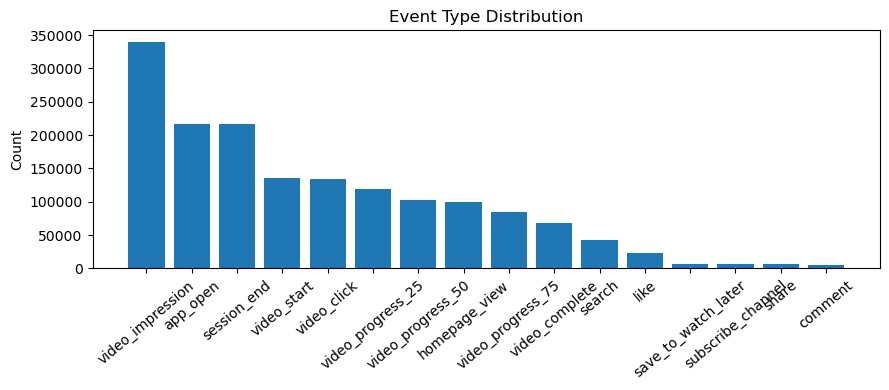

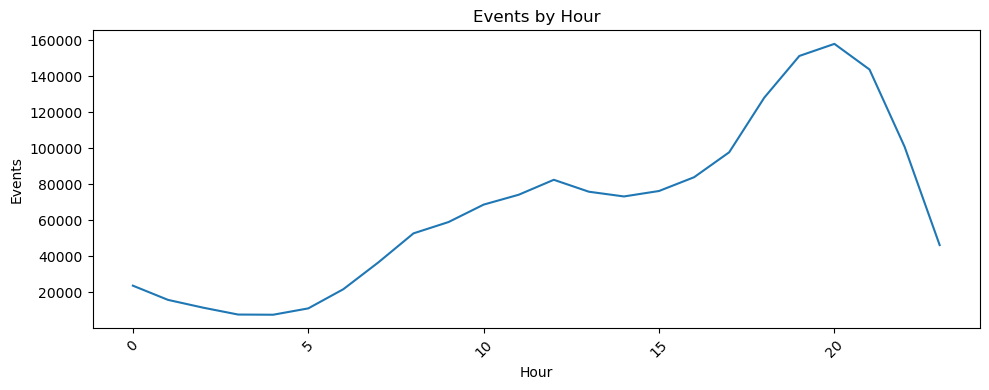

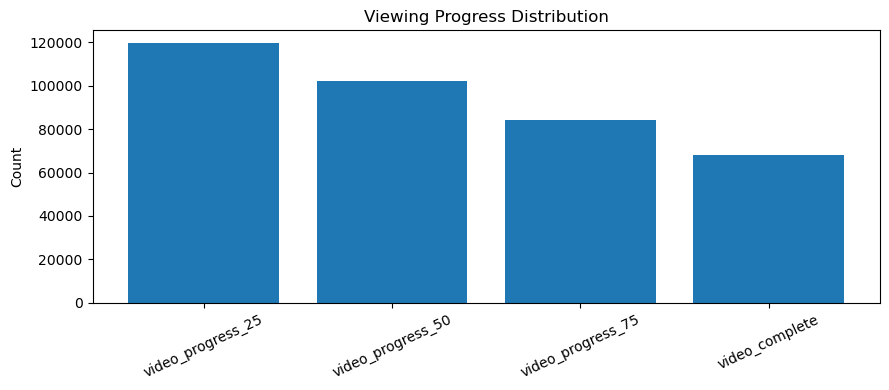

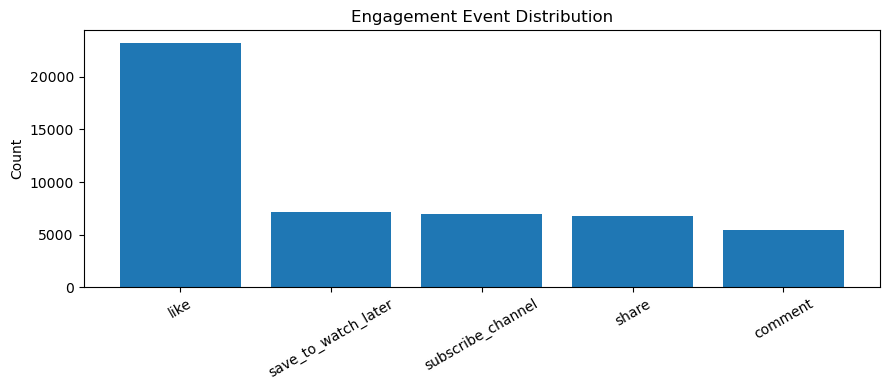

Most common viewer actions


,events
event_name,
video_impression,340095
app_open,216464
session_end,216464
video_start,134908
video_click,134585


Peak event hour: 20
Most common engagement action: like


In [6]:
# event analysis
event_counts = events["event_name"].value_counts()
events_by_hour = events["event_timestamp"].dt.hour.value_counts().sort_index()

progress_order = [
    "video_progress_25", "video_progress_50",
    "video_progress_75", "video_complete"
]
progress_counts = event_counts.reindex(progress_order).fillna(0)

engagement_order = [
    "like", "comment", "share",
    "subscribe_channel", "save_to_watch_later"
]
engagement_counts = event_counts.reindex(engagement_order).fillna(0)

bar_chart(event_counts, "Event Type Distribution", rotation=40)
line_chart(events_by_hour, "Events by Hour", "Hour", "Events")
bar_chart(progress_counts, "Viewing Progress Distribution", rotation=25, sort=False)
bar_chart(engagement_counts, "Engagement Event Distribution", rotation=30)

print("Most common viewer actions")
display(event_counts.head(5).rename("events").to_frame())
print("Peak event hour:", int(events_by_hour.idxmax()))
print("Most common engagement action:", engagement_counts.idxmax())

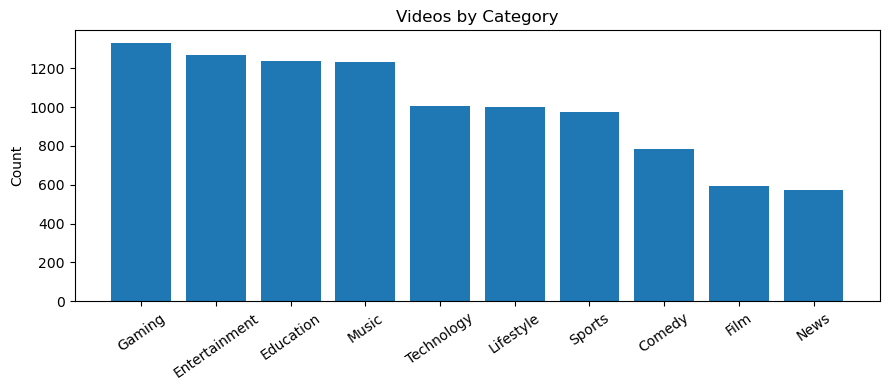

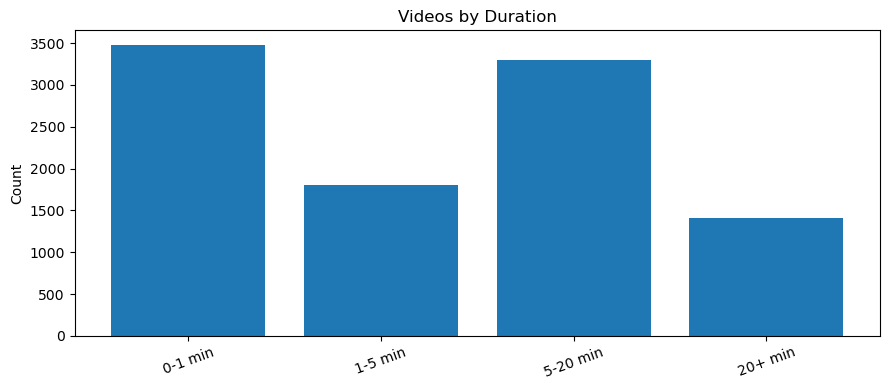

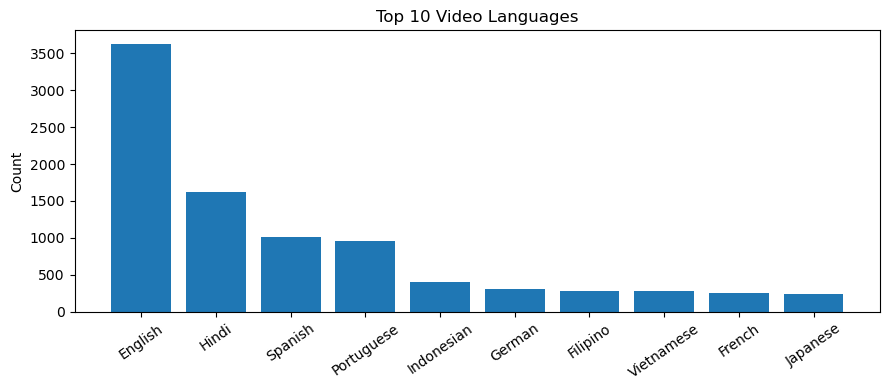

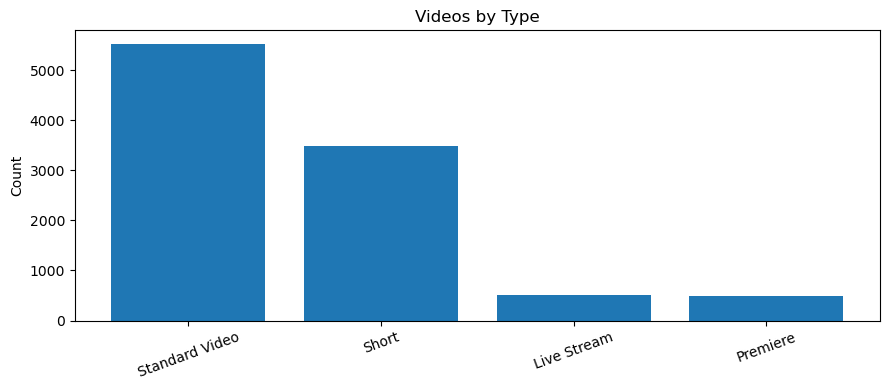

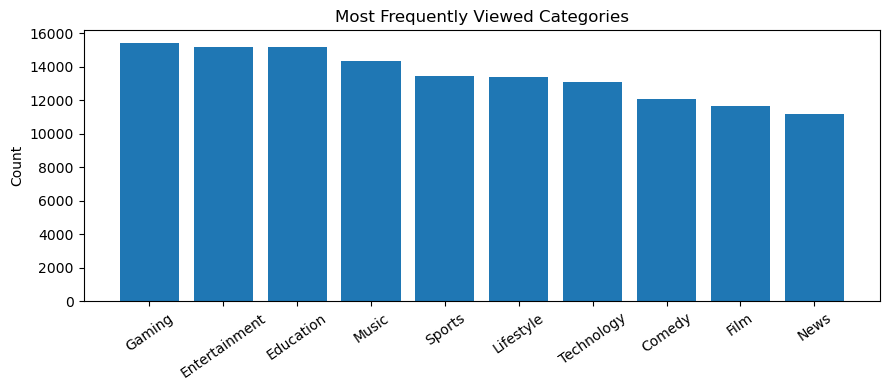

Content observations
Largest video category: Gaming
Most common video type: Standard Video
Most viewed category: Gaming


In [7]:
# content analysis
videos_by_category = videos["video_category"].value_counts()
videos_by_language = videos["video_language"].value_counts().head(10)
videos_by_type = videos["video_type"].value_counts()

videos["duration_group"] = pd.cut(
    videos["duration_seconds"],
    bins=[0, 60, 300, 1200, np.inf],
    labels=["0-1 min", "1-5 min", "5-20 min", "20+ min"],
    include_lowest=True
)
videos_by_duration = videos["duration_group"].value_counts().sort_index()

video_starts = (
    events.loc[events["event_name"].eq("video_start"), "video_id"]
    .value_counts()
    .rename("views")
)

viewed_categories = (
    videos[["video_id", "video_category"]]
    .merge(video_starts, left_on="video_id", right_index=True, how="left")
    .fillna({"views": 0})
    .groupby("video_category")["views"]
    .sum()
    .sort_values(ascending=False)
)

bar_chart(videos_by_category, "Videos by Category", rotation=35)
bar_chart(videos_by_duration, "Videos by Duration", rotation=20, sort=False)
bar_chart(videos_by_language, "Top 10 Video Languages", rotation=35)
bar_chart(videos_by_type, "Videos by Type", rotation=20)
bar_chart(viewed_categories, "Most Frequently Viewed Categories", rotation=35)

print("Content observations")
print("Largest video category:", videos_by_category.idxmax())
print("Most common video type:", videos_by_type.idxmax())
print("Most viewed category:", viewed_categories.idxmax())

Control users: 5939
Treatment users: 5916
Control percentage: 50.1 %
Treatment percentage: 49.9 %
Missing exposure dates: 0


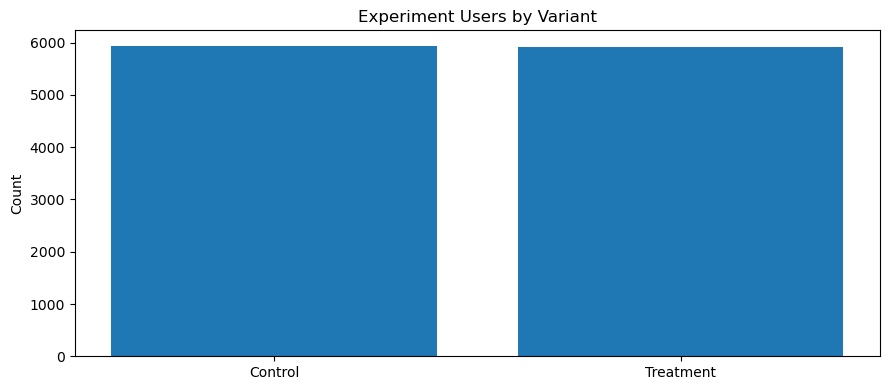

Subscription type by variant (%)


subscription_type,Free,Premium Trial,YouTube Premium
variant,,,
Control,77.9,7.2,14.9
Treatment,78.5,7.0,14.5


Preferred device by variant (%)


preferred_device,Desktop,Game Console,Mobile,TV,Tablet
variant,,,,,
Control,20.1,2.7,54.2,15.9,7.1
Treatment,20.4,3.0,54.6,14.7,7.3


Acquisition channel by variant (%)


acquisition_channel,Direct,Google Ads,Organic Search,Pre-installed App,Referral,Social Media
variant,,,,,,
Control,8.3,15.2,30.0,11.6,10.2,24.7
Treatment,8.1,14.8,30.3,11.5,10.2,25.3


The experiment groups are balanced and ready for analysis.


In [9]:
# experiment validation
# keeping only eligible experiment users
experiment_users = experiments[
    experiments["eligible_flag"] == True
].copy()

# counting control and treatment users
variant_counts = experiment_users["variant"].value_counts()

control_users = variant_counts.get("Control", 0)
treatment_users = variant_counts.get("Treatment", 0)
total_users = control_users + treatment_users

control_percent = round((control_users / total_users) * 100, 2)
treatment_percent = round((treatment_users / total_users) * 100, 2)

# checking missing exposure dates
missing_exposure_dates = experiment_users[
    "first_exposure_date"
].isna().sum()

print("Control users:", control_users)
print("Treatment users:", treatment_users)
print("Control percentage:", control_percent, "%")
print("Treatment percentage:", treatment_percent, "%")
print("Missing exposure dates:", missing_exposure_dates)

bar_chart(
    variant_counts,
    "Experiment Users by Variant"
)

# adding user details to the experiment data
experiment_users = experiment_users.merge(
    users[
        [
            "user_id",
            "subscription_type",
            "preferred_device",
            "acquisition_channel"
        ]
    ],
    on="user_id",
    how="left"
)

# comparing subscription types
subscription_mix = pd.crosstab(
    experiment_users["variant"],
    experiment_users["subscription_type"],
    normalize="index"
).mul(100).round(1)

print("Subscription type by variant (%)")
display(subscription_mix)

# comparing preferred devices
device_mix = pd.crosstab(
    experiment_users["variant"],
    experiment_users["preferred_device"],
    normalize="index"
).mul(100).round(1)

print("Preferred device by variant (%)")
display(device_mix)

# comparimg acquisition channels
acquisition_mix = pd.crosstab(
    experiment_users["variant"],
    experiment_users["acquisition_channel"],
    normalize="index"
).mul(100).round(1)

print("Acquisition channel by variant (%)")
display(acquisition_mix)

# checking assignment balance
balance_gap = abs(control_percent - treatment_percent)

if balance_gap <= 2 and missing_exposure_dates == 0:
    print("The experiment groups are balanced and ready for analysis.")
else:
    print("The experiment groups need to be checked before analysis.")